# Custom Diagram Layout Templates
This notebook is for development and documentation of custom diagram layout templates. 

A Custom Diagram Layout Template is defined by a data structure that specifies 
the Structure and its relative location on the diagram.  The templates are 
"Custom" because their definition can be stored in a Jason file and loaded into 
the program. This allows for the creation of new templates without having to 
modify the code.

The definition is in the following format:

```json
{
    "template_name": "Template Name",
    "template_description": "Template Description",
    "template_version": "1.0",
    "template_author": "Author Name",
    "template_date": "2024-06-01",
    "template_layout": {
        "Structure ID 1": {
            "x": 0,
            "y": 0
        },
        "Structure ID 2": {
            "x": 1,
            "y": 0
        },
        ...
    }
}
```

In the initial implementation only an exactly matching "Structure ID" will be 
accepted.


The diagram_layout module will contain a dataclass defining the Custom Diagram 
Layout format.  It will also be used to load the templates from a Jason file,
validate the templates and make them accessible via the existing 
`get_layout_template` function, also in the diagram_layout module. 

The diagram_layout module will also have a public function to add new templates 
to the existing templates by accepting a template definition in the above 
format and adding it to the existing templates.

The diagram rendering function will use the existing `render_template_diagram` 
function to render the diagram based on the loaded template. 

## Setup

### Imports

        diagram_settings_def = config_path / 'diagram_settings.json'

In [1]:
from pathlib import Path

from pprint import pprint

#### Public Packages

In [2]:
import pandas as pd


#### Local Modules

In [3]:
from structure_set import StructureSet

from dicom import DicomStructureFile

from diagram_layout import get_layout_template, add_custom_layout_template, load_custom_template_from_file

from diagram_rendering import render_template_diagram


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [4]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
config_path = base_path / r'src/webapp/config'
structure_filter_def = config_path / 'structure_filter_rules.json'
diagram_settings_def = config_path / 'diagram_settings.json'
layout_templates_path = base_path / 'src/layout_templates'


## Example CNS DICOM structure set

### Load the example DICOM file and generate the Structure Set

In [5]:
dcm_file_name = 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

# Use the structure filter rules to determine which structures to load.
filter_report = dicom_file.evaluate_structure_filters()
include_structures = list(filter_report.loc[filter_report['SelectedByDefault'],
                                            'Structure ID'])

# Determine the relationships between the structures
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)


INFO:dicom:Successfully loaded DICOM dataset from RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Extracted 2911 contours from 35 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.040 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.CNS_FSRT_2_GTV.BRAI.dcm"),
 'PatientID': 'CNS_FSRT_2_GTV',
 'PatientLastName': 'CNS_FSRT_2_GTV_Partition_Error',
 'PatientName': 'CNS_FSRT_2_GTV_Partition_Error',
 'SeriesDescription': '',
 'SeriesNumber': '0',
 'StructureSet': 'BRAI',
 'StudyID': ''}


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


The layout from the 'Optics' template should look something like this:

![alt text](<../../../reference/Example Diagrams/Optics Layout.png>)


### Display the diagram using the custom layout template

In [6]:
optics_template = {
    "template_name": "Optics",
    "template_description": "Relationship between the optic structures including the eyes and related PRV structures",
    "template_version": "1.0",
    "template_author": "Greg's Test",
    "template_date": "2024-06-01",
    "template_layout": {
        'OpticChiasm': {
            "x": 0,
            "y": 0
        },
        'Globe L': {
            "x": -1,
            "y": 0
        },
        'Globe R': {
            "x": 1,
            "y": 0
        },
        'Lens L': {
            "x": -1,
            "y": -1
        },
        'Lens R': {
            "x": 1,
            "y": -1
        },
        'OpticNerve L': {
            "x": -1,
            "y": 1
        },
        'OpticNerve R': {
            "x": 1,
            "y": 1
        },
        'PRV5 Optics': {
            "x": 0,
            "y": -1
        }
    }
}

add_custom_layout_template(optics_template)

LayoutTemplate(name='Optics', display_by_default=True, display_rules=(), grouping_definition_set=None, algorithm=CustomLayoutAlgorithm(), plan_builder=CustomLayoutPlanBuilder(definition=CustomDiagramLayoutDefinition(template_name='Optics', template_description='Relationship between the optic structures including the eyes and related PRV structures', template_version='1.0', template_author="Greg's Test", template_date='2024-06-01', template_layout={'OpticChiasm': (0.0, 0.0), 'Globe L': (-1.0, 0.0), 'Globe R': (1.0, 0.0), 'Lens L': (-1.0, -1.0), 'Lens R': (1.0, -1.0), 'OpticNerve L': (-1.0, 1.0), 'OpticNerve R': (1.0, 1.0), 'PRV5 Optics': (0.0, -1.0)})))

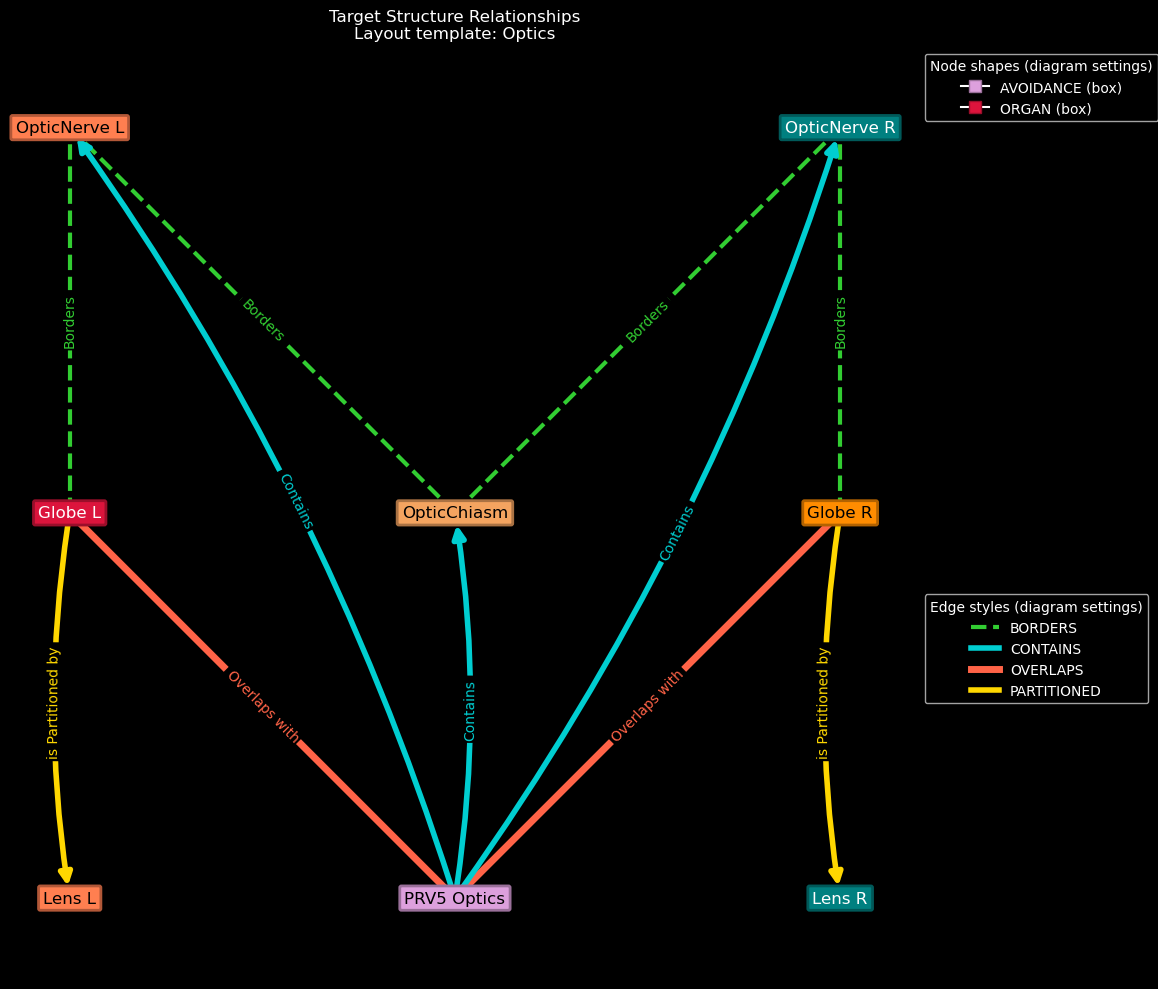

In [7]:
layout_template = get_layout_template('Optics')
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=diagram_settings_def,
    hide_logical_edges=True,
    show_plot=True,
    )


## Loading from a JSON file

The same template can be stored as `src/layout_templates/optics_template.json` and
loaded without any code changes. The JSON file uses `template_name: "Optics_JSON"` so
it can be registered in the same session alongside the dict-defined `"Optics"` template.


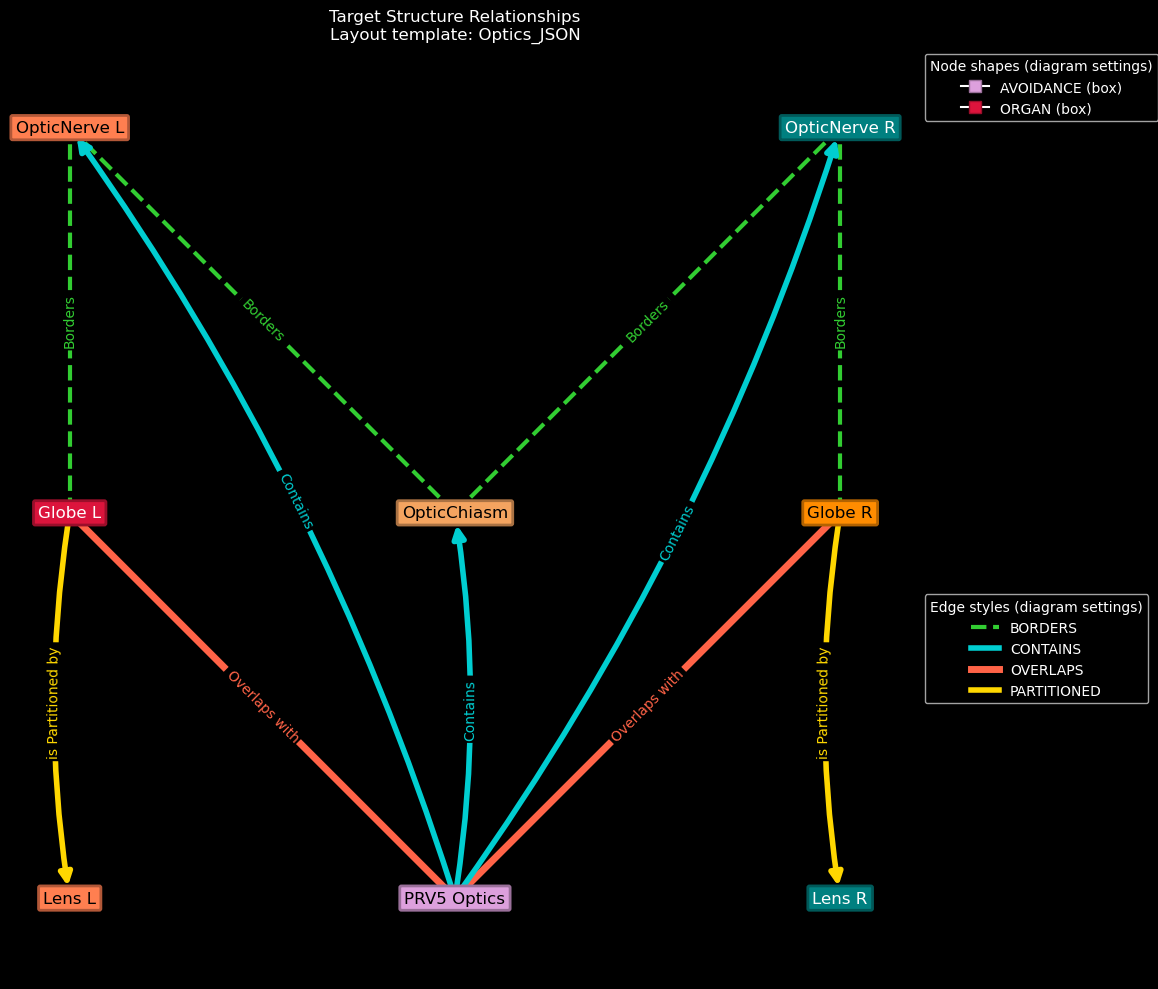

In [8]:
json_template = load_custom_template_from_file(
    layout_templates_path / 'optics_template.json',
)
json_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=json_template,
    diagram_settings_path=diagram_settings_def,
    hide_logical_edges=True,
    show_plot=True,
)


## Load an example H&N DICOM structure set

In [9]:
dcm_file_name = 'RS.HN_Struct.OROP.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

# Use the structure filter rules to determine which structures to load.
filter_report = dicom_file.evaluate_structure_filters()
include_structures = list(filter_report.loc[filter_report['SelectedByDefault'],
                                            'Structure ID'])

# Determine the relationships between the structures
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)


INFO:dicom:Successfully loaded DICOM dataset from RS.HN_Struct.OROP.dcm
INFO:dicom:Extracted 3666 contours from 61 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.HN_Struct.OROP.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.070 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.HN_Struct.OROP.dcm"),
 'PatientID': 'HN_Struct',
 'PatientLastName': 'Head',
 'PatientName': 'Head^and^Neck^Structures',
 'SeriesDescription': 'ARIA RadOnc Structure Sets',
 'SeriesNumber': '234',
 'StructureSet': 'OROP',
 'StudyID': ''}


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


#### Parotid and Submandibular Glands Layout Example

![alt text](<../../../reference/Example Diagrams/Glands Layout.png>)



### Define the layout template to use for the diagram


In [10]:
glands_template = {
    "template_name": "Salivary Glands",
    "template_description": "Parotid and submandibular glands layout template",
    "template_version": "1.0",
    "template_author": "Greg's Test",
    "template_date": "2024-06-01",
    "template_layout": {
        'Mandible': {
            "x": 0,
            "y": 0
        },
        'Parotid B': {
            "x": -2,
            "y": 0.75
        },
        'Parotid R': {
            "x": -3,
            "y": -0.75
        },
        'Parotid L': {
            "x": -1,
            "y": -0.75
        },
        'Submandibular B': {
            "x": 2,
            "y": 0.75
        },
        'Submandibular R': {
            "x": 1,
            "y": -0.75
        },
        'Submandibular L': {
            "x": 3,
            "y": -0.75
        },
        'opt Parotid R': {
            "x": -3,
            "y": 0.1
        },
        'opt Parotid L': {
            "x": -1,
            "y": -0.1
        }
    }
}

add_custom_layout_template(glands_template)


LayoutTemplate(name='Salivary Glands', display_by_default=True, display_rules=(), grouping_definition_set=None, algorithm=CustomLayoutAlgorithm(), plan_builder=CustomLayoutPlanBuilder(definition=CustomDiagramLayoutDefinition(template_name='Salivary Glands', template_description='Parotid and submandibular glands layout template', template_version='1.0', template_author="Greg's Test", template_date='2024-06-01', template_layout={'Mandible': (0.0, 0.0), 'Parotid B': (-2.0, 0.75), 'Parotid R': (-3.0, -0.75), 'Parotid L': (-1.0, -0.75), 'Submandibular B': (2.0, 0.75), 'Submandibular R': (1.0, -0.75), 'Submandibular L': (3.0, -0.75), 'opt Parotid R': (-3.0, 0.1), 'opt Parotid L': (-1.0, -0.1)})))

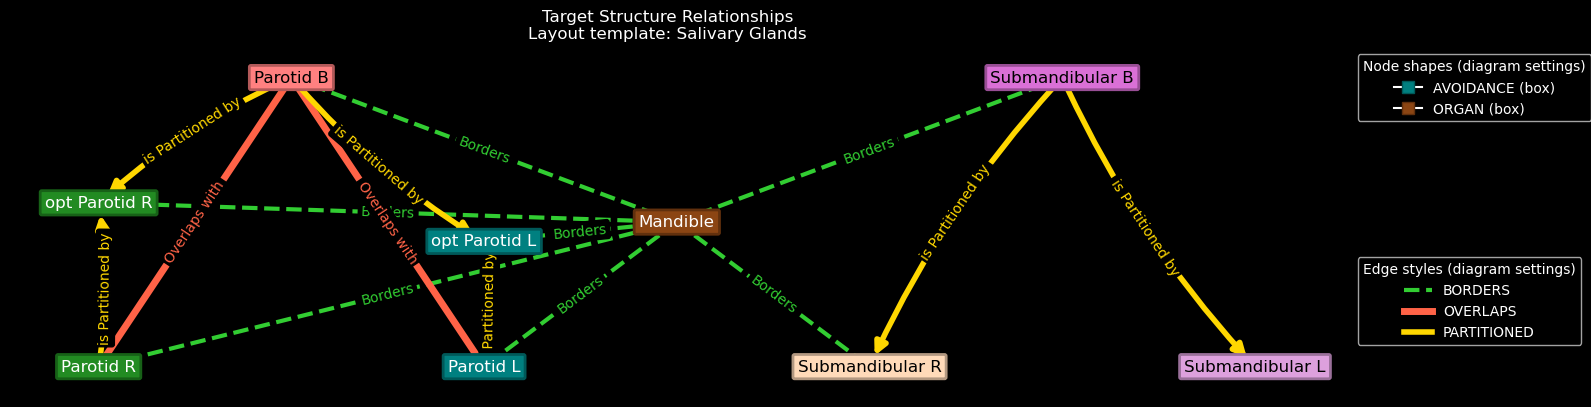

In [11]:
layout_template = get_layout_template('Salivary Glands')
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=diagram_settings_def,
    hide_logical_edges=True,
    show_plot=True,
    )